# Retail store data analysis

#The goal of this Exploratory Data Analysis (EDA) is to uncover key purchasing patterns and demographic insights to optimize sales strategies. 

Core Questions Addressed:

1. Total amount by category
2. Discount over previous purchases
3. Amount by payment method
4. Total Amount by gender
5. Top 10 item purchased
6. Avg rating by Age Group
7. Correlation of numerical columns



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("retail_store_sales.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [4]:
df.shape

(5000, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   str    
 3   Category            5000 non-null   str    
 4   ItemPurchased       5000 non-null   str    
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   str    
 7   PaymentMethod       5000 non-null   str    
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 598.4 KB


In [6]:
df.describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.isna().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

In [9]:
df.columns


Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')

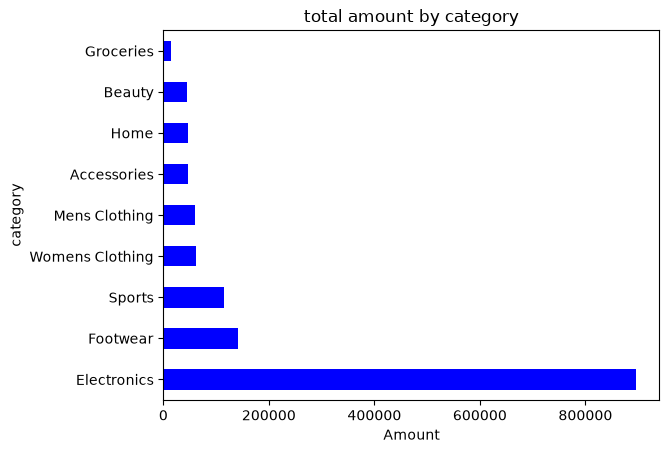

In [10]:
# total amount by category
df.groupby('Category')['Amount'].sum().sort_values(ascending = False).plot(kind= 'barh' ,color= 'blue')
plt.title('total amount by category')
plt.xlabel('Amount')
plt.ylabel('category')
plt.show()

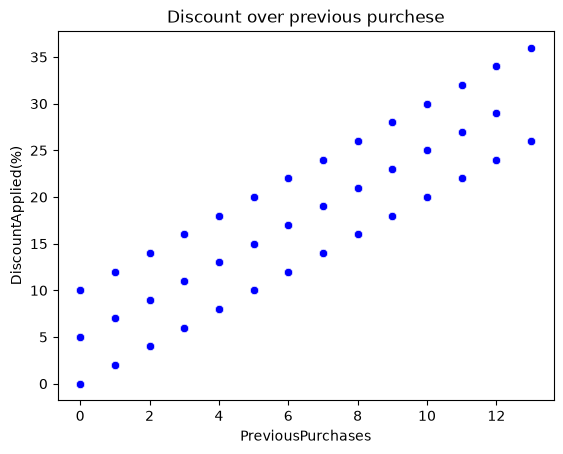

In [11]:
# discount over previous purchases
sns.scatterplot(data = df , x='PreviousPurchases', y='DiscountApplied(%)' , color='blue')
plt.title('Discount over previous purchese')
plt.show()


In [12]:
df.columns


Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')

Text(0.5, 1.0, 'Amount by payment method')

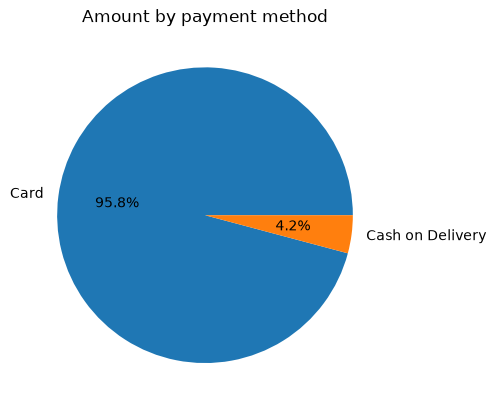

In [13]:
# amount by payment method
df.groupby('PaymentMethod')['Amount'].sum().plot(kind='pie',autopct='%1.1f%%')
plt.title('Amount by payment method')

Text(0.5, 1.0, 'Total amount by Gender')

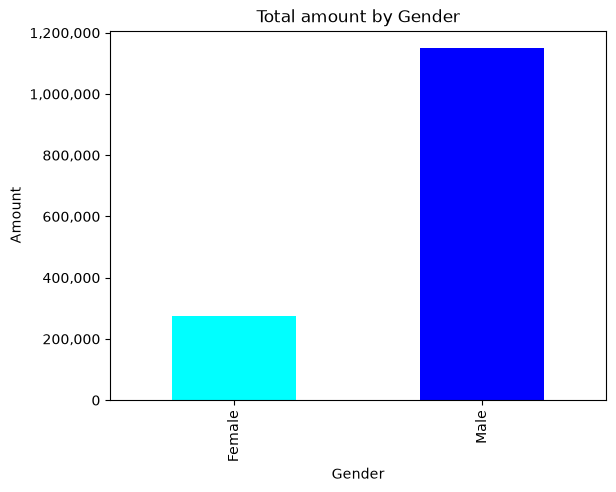

In [14]:
#total amount by gender
ax = df.groupby('Gender')['Amount'].sum().plot(kind='bar',color = ['cyan','blue'])
plt.xlabel('Gender')
plt.ylabel('Amount')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.title('Total amount by Gender')

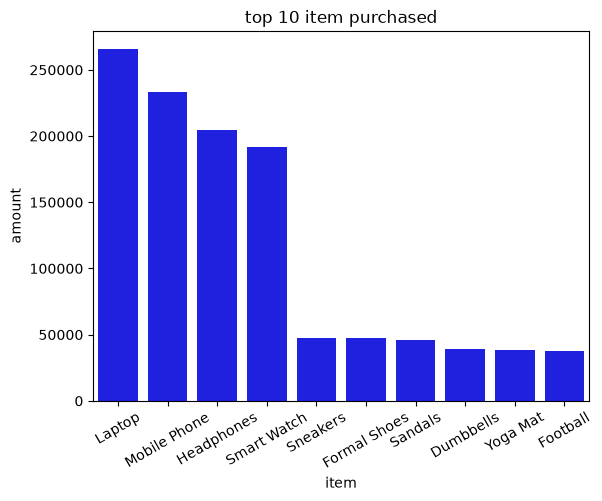

In [15]:
#top 10 item purchased
itempurchased_by_amount=df.groupby('ItemPurchased')['Amount'].sum().sort_values(ascending = False).head(10)
sns.barplot(data=itempurchased_by_amount,color='blue')
plt.title('top 10 item purchased')
plt.xlabel('item')
plt.ylabel('amount')
plt.xticks(rotation=30)
plt.show()
           


In [16]:
df['Age_Group'] = df['Age'].apply(lambda age: 'Child' if age<18
        else 'Adult' if age<35
        else 'Senior')

In [17]:
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Age_Group
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,Senior
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,Senior
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,Senior
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,Senior
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,Adult


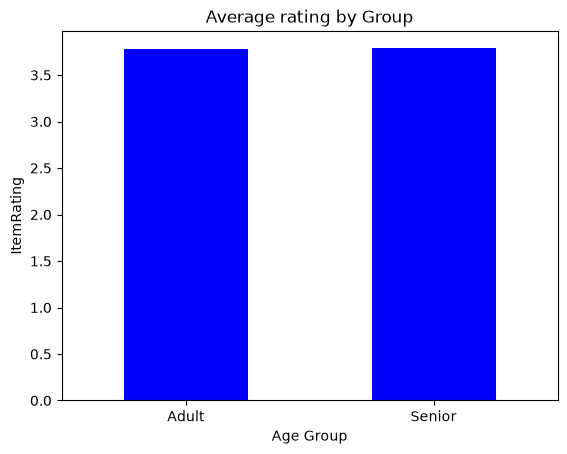

In [18]:
# Avg rating by age group
df.groupby('Age_Group')['ItemRating'].mean().plot(kind='bar',color='blue')
plt.title('Average rating by Group')
plt.xlabel('Age Group')
plt.xticks(rotation = 0)
plt.ylabel('ItemRating')
plt.show()

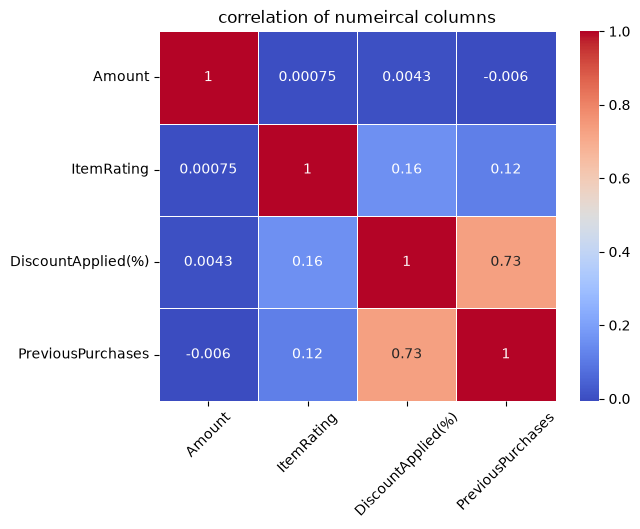

In [19]:
#correlation bw numerical columns
sns.heatmap(df[['Amount','ItemRating','DiscountApplied(%)','PreviousPurchases']].corr(),annot = True , cmap = 'coolwarm', linewidths=0.5)
plt.title('correlation of numeircal columns')
plt.xticks(rotation=45)
plt.show()